In [12]:
%load_ext autoreload
%autoreload 2

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from notebooks.summersoc.globals import PATH_METRICS_DEMO_EXPLORE, PATH_MODEL_LIST, ITERATE_THROUGH_X_PARTS, \
    SPLIT_DATA_INTO_X_PARTS, PATH_METRICS_DEMO_EXPLOIT

plt.style.use('default')

from agent.components import RASK
from agent.components.GaussianProcess import GASK
from agent.components.commons import ServiceType, FIG_SIZE_DEFAULT
from agent.components.commons import SloSet

services = [ServiceType.QR, ServiceType.CV, ServiceType.PC]
slos = [SloSet.DEFAULT, SloSet.HIGH_PERF, SloSet.LOW_COST, SloSet.HIGH_QUALITY]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
_df_explore = pd.read_csv(PATH_METRICS_DEMO_EXPLORE)
_df_exploit = pd.read_csv(PATH_METRICS_DEMO_EXPLOIT)
df_joint = pd.concat([_df_explore, _df_exploit])
df_preprocessed = RASK.preprocess_data(df_joint)

INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str


## **Analyze**: Regression Analysis of Structural Knowledge

### Create Structural Knowledge

Purpose is to identify structural dependencies directly from data

Also helps to determine which metrics to track, and for the tracked ones, which resolution to choose.

Please talk to **Nefeli Marina Rouska** if you find this interesting

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered,O=Categorical Ordered)inferred from data: 
 {'cores': 'N', 'throughput': 'N', 'data_quality': 'N'}


  0%|          | 0/5 [00:00<?, ?it/s]

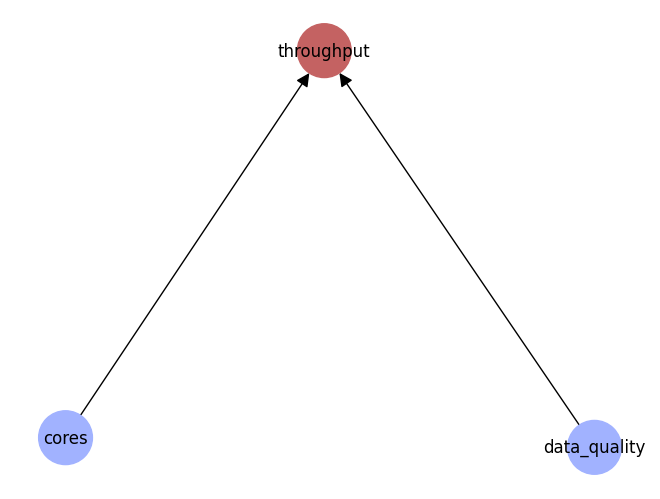

In [3]:
from utils import visualize_DAG

from pgmpy.base import DAG
from pgmpy.causal_discovery import PC

df_filtered = df_preprocessed[df_preprocessed['service_type'] == ServiceType.QR.value]
df_filtered = df_filtered[['cores', 'throughput', 'data_quality']]

estimator = PC().fit(df_filtered)
dag: DAG = estimator.causal_graph_

regular = '#a1b2ff'  # blue
special = '#c46262'  # red

visualize_DAG(dag, color_map=[regular, special, regular])

### Functional Data Analysis

Note that both variants commonly benefit from removing outliers from the dataset; in our case, it was not needed according to our judgment.



In [4]:
rm_list = []
gp_list = []
lml_history = []

#### Variant 1: Using a Simple Regression Model

Low complexity (TODO: give the asymptotic runtime and the actual physical runtime)

No uncertainty

INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str
INFO:multiscale:init_models took 9 ms to execute
INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str
INFO:multiscale:init_models took 8 ms to execute
INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str
INFO:multiscale:init_models took 8 ms to execute
INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str
INFO:multiscale:init_models took 8 ms to execute
INFO:multiscale:Trai

Finished fitting 1 / 60 of the Regression Models
Finished fitting 2 / 60 of the Regression Models
Finished fitting 3 / 60 of the Regression Models
Finished fitting 4 / 60 of the Regression Models
Finished fitting 5 / 60 of the Regression Models
Finished fitting 6 / 60 of the Regression Models
Finished fitting 7 / 60 of the Regression Models
Finished fitting 8 / 60 of the Regression Models
Finished fitting 9 / 60 of the Regression Models
Finished fitting 10 / 60 of the Regression Models
Finished fitting 11 / 60 of the Regression Models
Finished fitting 12 / 60 of the Regression Models
Finished fitting 13 / 60 of the Regression Models
Finished fitting 14 / 60 of the Regression Models


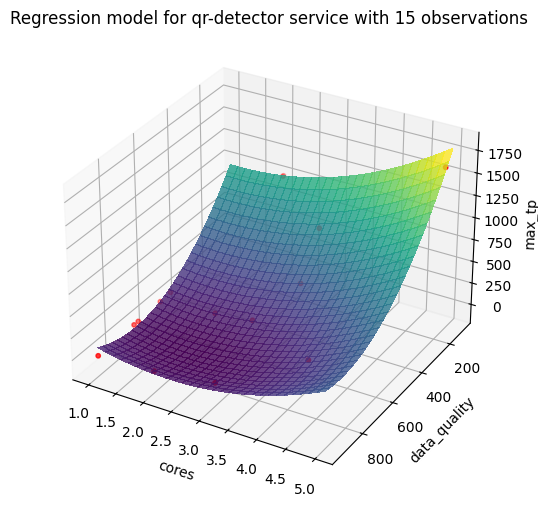

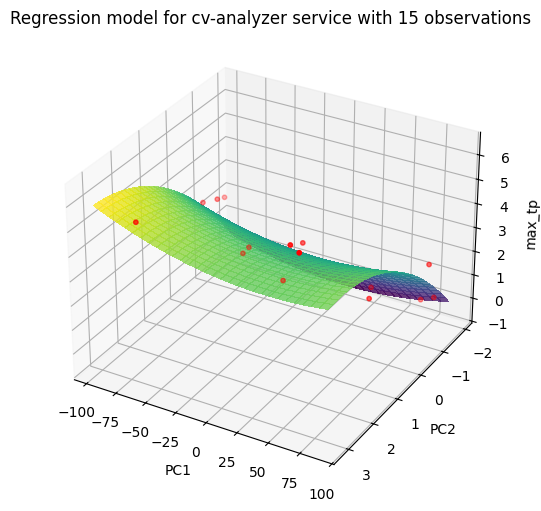

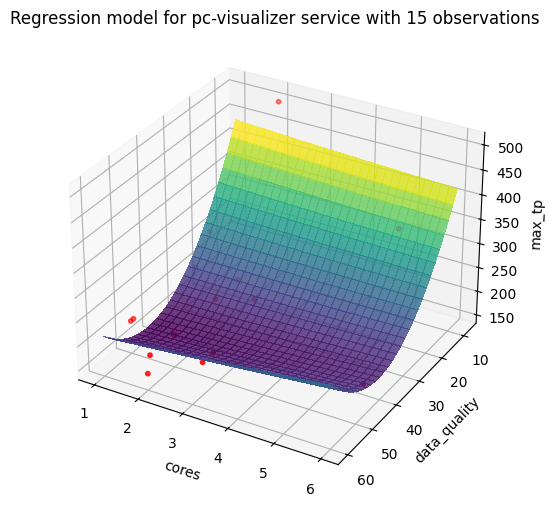

INFO:multiscale:init_models took 328 ms to execute
INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str
INFO:multiscale:init_models took 10 ms to execute
INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str
INFO:multiscale:init_models took 9 ms to execute
INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str
INFO:multiscale:init_models took 10 ms to execute
INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str
INFO:multiscale:

Finished fitting 15 / 60 of the Regression Models
Finished fitting 16 / 60 of the Regression Models
Finished fitting 17 / 60 of the Regression Models
Finished fitting 18 / 60 of the Regression Models
Finished fitting 19 / 60 of the Regression Models
Finished fitting 20 / 60 of the Regression Models
Finished fitting 21 / 60 of the Regression Models
Finished fitting 22 / 60 of the Regression Models
Finished fitting 23 / 60 of the Regression Models
Finished fitting 24 / 60 of the Regression Models
Finished fitting 25 / 60 of the Regression Models
Finished fitting 26 / 60 of the Regression Models
Finished fitting 27 / 60 of the Regression Models
Finished fitting 28 / 60 of the Regression Models
Finished fitting 29 / 60 of the Regression Models
Finished fitting 30 / 60 of the Regression Models
Finished fitting 31 / 60 of the Regression Models
Finished fitting 32 / 60 of the Regression Models
Finished fitting 33 / 60 of the Regression Models
Finished fitting 34 / 60 of the Regression Models


INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str
INFO:multiscale:init_models took 9 ms to execute
INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str
INFO:multiscale:init_models took 9 ms to execute
INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str
INFO:multiscale:init_models took 10 ms to execute
INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str
INFO:multiscale:init_models took 10 ms to execute
INFO:multiscale:Tr

Finished fitting 35 / 60 of the Regression Models
Finished fitting 36 / 60 of the Regression Models
Finished fitting 37 / 60 of the Regression Models
Finished fitting 38 / 60 of the Regression Models
Finished fitting 39 / 60 of the Regression Models
Finished fitting 40 / 60 of the Regression Models
Finished fitting 41 / 60 of the Regression Models
Finished fitting 42 / 60 of the Regression Models
Finished fitting 43 / 60 of the Regression Models
Finished fitting 44 / 60 of the Regression Models
Finished fitting 45 / 60 of the Regression Models
Finished fitting 46 / 60 of the Regression Models
Finished fitting 47 / 60 of the Regression Models
Finished fitting 48 / 60 of the Regression Models
Finished fitting 49 / 60 of the Regression Models
Finished fitting 50 / 60 of the Regression Models
Finished fitting 51 / 60 of the Regression Models
Finished fitting 52 / 60 of the Regression Models
Finished fitting 53 / 60 of the Regression Models


INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str
INFO:multiscale:init_models took 9 ms to execute
INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str
INFO:multiscale:init_models took 9 ms to execute
INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str
INFO:multiscale:init_models took 9 ms to execute
INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str
INFO:multiscale:init_models took 10 ms to execute
INFO:multiscale:Tra

Finished fitting 54 / 60 of the Regression Models
Finished fitting 55 / 60 of the Regression Models
Finished fitting 56 / 60 of the Regression Models
Finished fitting 57 / 60 of the Regression Models
Finished fitting 58 / 60 of the Regression Models
Finished fitting 59 / 60 of the Regression Models


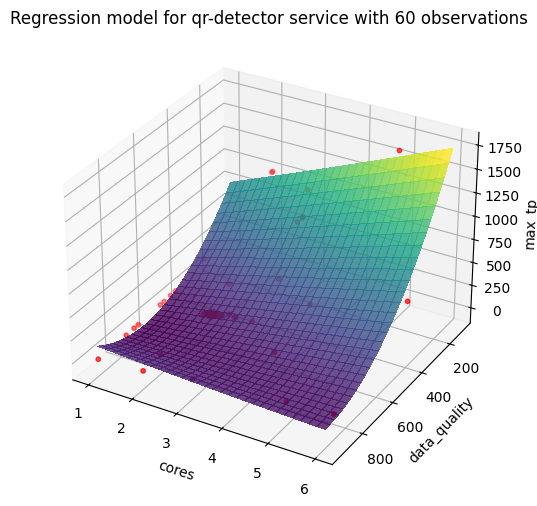

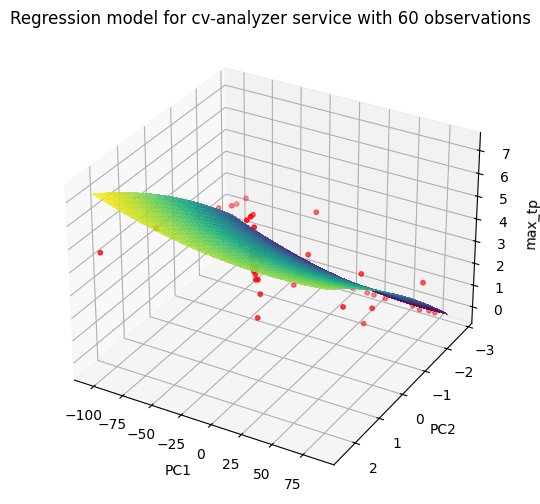

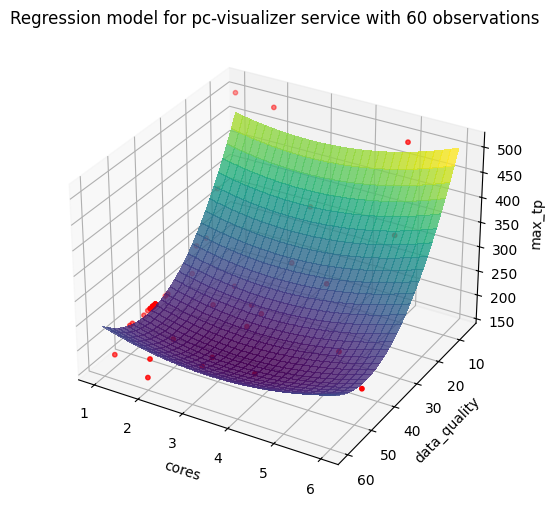

INFO:multiscale:init_models took 430 ms to execute


Finished fitting 60 / 60 of the Regression Models


In [5]:
from agent.components.RASK import RASK

rm_list = []

for i in range(ITERATE_THROUGH_X_PARTS):
    rm_all_services = {}
    data_ratio = (i + 1) / SPLIT_DATA_INTO_X_PARTS

    draw_figures = i == (ITERATE_THROUGH_X_PARTS / 4) - 1 or i == ITERATE_THROUGH_X_PARTS - 1
    _rm = RASK(show_figures=draw_figures)
    _rm.init_models(df_joint, data_density=data_ratio)
    rm_list.append(_rm)

    print(f"Finished fitting {i + 1} / {ITERATE_THROUGH_X_PARTS} of the Regression Models")


#### Variant 2: Using a Gaussian Process

Medium complexity

Has uncertainty

In [7]:
import plotly.io as pio

pio.renderers.default = 'browser'

gp_list = []
lml_history = []

for i in range(ITERATE_THROUGH_X_PARTS):
    gp_all_services = {}
    data_ratio = (i + 1) / SPLIT_DATA_INTO_X_PARTS
    lml_all_service = []

    for s in services:
        # Initialize and train GP model
        draw_figures = i == (ITERATE_THROUGH_X_PARTS / 4) - 1 or i == ITERATE_THROUGH_X_PARTS - 1
        _gp = GASK(s, create_figures=draw_figures, display_figures=draw_figures)
        _gp.init_model(df_joint, data_density=data_ratio)

        _lml = _gp.get_model_lml(s, "max_tp")
        lml_scaled = _lml / data_ratio
        lml_all_service.append(lml_scaled)
        gp_all_services[s] = _gp

    lml_history.append(lml_all_service)
    gp_list.append(gp_all_services)

    print(f"Finished fitting {i + 1} / {ITERATE_THROUGH_X_PARTS} of the Gaussian Processes")



INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str
INFO:GP_Model:Fitting GP for elastic-workbench-qr-detector - Target: max_tp
C:\Users\boris\development\composable-autonomous-offerings\venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__sigma_0 is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\boris\development\composable-autonomous-offerings\venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__k1__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
INFO:multiscale:train_gp_models took 1

Finished fitting 1 / 60 of the Gaussian Processes
Finished fitting 2 / 60 of the Gaussian Processes
Finished fitting 3 / 60 of the Gaussian Processes
Finished fitting 4 / 60 of the Gaussian Processes


C:\Users\boris\development\composable-autonomous-offerings\venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__sigma_0 is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
INFO:multiscale:train_gp_models took 16 ms to execute
INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str
INFO:GP_Model:Fitting GP for elastic-workbench-cv-analyzer - Target: max_tp
C:\Users\boris\development\composable-autonomous-offerings\venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__sigma_0 is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warning

Finished fitting 5 / 60 of the Gaussian Processes
Finished fitting 6 / 60 of the Gaussian Processes
Finished fitting 7 / 60 of the Gaussian Processes
Finished fitting 8 / 60 of the Gaussian Processes


INFO:GP_Model:Fitting GP for elastic-workbench-qr-detector - Target: max_tp
C:\Users\boris\development\composable-autonomous-offerings\venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__sigma_0 is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
INFO:multiscale:train_gp_models took 20 ms to execute
INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str
INFO:GP_Model:Fitting GP for elastic-workbench-cv-analyzer - Target: max_tp
C:\Users\boris\development\composable-autonomous-offerings\venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__sigma_0 is close to the specified lower bound 0.01. D

...

Finished fitting 54 / 60 of the Gaussian Processes
Finished fitting 55 / 60 of the Gaussian Processes
Finished fitting 56 / 60 of the Gaussian Processes


INFO:GP_Model:Fitting GP for elastic-workbench-qr-detector - Target: max_tp
INFO:multiscale:train_gp_models took 21 ms to execute
INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str
INFO:GP_Model:Fitting GP for elastic-workbench-cv-analyzer - Target: max_tp
C:\Users\boris\development\composable-autonomous-offerings\venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__sigma_0 is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\boris\development\composable-autonomous-offerings\venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__k1__constant_value is close to the specified lower bound 

Finished fitting 57 / 60 of the Gaussian Processes
Finished fitting 58 / 60 of the Gaussian Processes
Finished fitting 59 / 60 of the Gaussian Processes


INFO:multiscale:draw_3d_gp_plot took 162 ms to execute
INFO:multiscale:train_gp_models took 186 ms to execute
INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str
INFO:GP_Model:Fitting GP for elastic-workbench-cv-analyzer - Target: max_tp
C:\Users\boris\development\composable-autonomous-offerings\venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__sigma_0 is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\boris\development\composable-autonomous-offerings\venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__k1__constant_value is close to the specified lower bound 0.001. Decreasing th

Finished fitting 60 / 60 of the Gaussian Processes


In [13]:
joblib.dump({'gp_list': gp_list, 'rm_list': rm_list}, PATH_MODEL_LIST)

['..\\..\\statics\\var_dumps\\2_analysis_models.joblib']

#### Create LML Figure

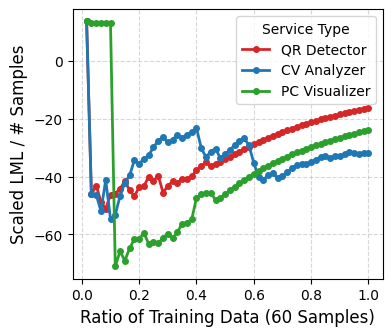

In [9]:
# 1. Define the X-axis (Data Ratios)
data_ratios = np.arange(1, ITERATE_THROUGH_X_PARTS + 1) / SPLIT_DATA_INTO_X_PARTS

# 2. Create the Figure
plt.figure(figsize=FIG_SIZE_DEFAULT)

# Service labels matching your 'services' list order
labels = ['QR Detector', 'CV Analyzer', 'PC Visualizer']
colors = ['#d62728', '#1f77b4', '#2ca02c']  # Red, Blue, Green


lml_array = np.array(lml_history)

for i in range(lml_array.shape[1]):
    plt.plot(data_ratios * (SPLIT_DATA_INTO_X_PARTS / ITERATE_THROUGH_X_PARTS), lml_array[:, i],
             marker='o', markersize=4, linewidth=2,
             label=labels[i], color=colors[i])

# 3. Formatting
abs_samples = int(len(df_joint) * (ITERATE_THROUGH_X_PARTS / SPLIT_DATA_INTO_X_PARTS))
plt.xlabel(f'Ratio of Training Data ({int(abs_samples / 3)} Samples)', fontsize=12)
plt.ylabel('Scaled LML / # Samples', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Service Type")
plt.show()